# Evaluate saved Random Forest age classifiers

Load saved RF pipelines (`.joblib` / `.pkl`) from `create_age_classifier.ipynb` and score them on a **stratified validation holdout** with the **same** preprocessing and `RANDOM_STATE` as training.

**Important:** `main()` saves the pipeline after a **final refit on all training rows**. Predicting on the validation fold with that artifact is **in-sample** (often ~100% accuracy). By default this notebook **clones hyperparameters** from the saved pipeline, **refits on the train fold only**, and evaluates on the held-out validation fold — matching the holdout accuracy embedded in the filename.

Set `EVAL_ON_SAVED_FULL_FIT=True` only to inspect in-sample behavior on the saved artifact. Optional `VAL_SUBSAMPLE_*` limits how many validation rows are scored.

In [9]:
from __future__ import annotations

import sys
from pathlib import Path

import warnings

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from heart_age_classifier import (
    evaluate_and_visualize_model,
    load_fitted_pipeline,
    load_train_pair,
    plot_validation_normalized_confusion_matrices,
)

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

_root = NOTEBOOK_DIR.resolve()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

assert (_root / "heart_age_classifier.py").is_file(), (
    f"Expected heart_age_classifier.py in {_root} (got cwd={Path.cwd()})"
)

## Settings

Preprocessing block matches **`create_age_classifier.ipynb` → Shared settings**. Set `VAL_SUBSAMPLE_FRACTION` / `VAL_SUBSAMPLE_N` to score a random validation subset (reproducible via `VAL_SUBSAMPLE_SEED`).

In [10]:
# --- Saved model(s) ---
MODEL_PATH = '/Users/brycesmith/Documents/MaXentric/4359_STRETCH/Proposals/DARPA/DTC Data/models/heart_age_rf_acc674_hp_max_depth-20__min_samples_leaf-1__n_estimators-100.joblib'
MODEL_PATHS: list[Path] | None = None  # e.g. [NOTEBOOK_DIR / "models" / "heart_age_rf_acc986.joblib"]

# Optional: override train CSV paths (None -> datasets/train beside this notebook)
training_csvs = None  # e.g. (NOTEBOOK_DIR / "datasets/train/aortaP_train_data.csv", ...)

# --- Features (match create_age_classifier.ipynb) ---
FEATURE_MODE = "waveform_plus"  # "engineered" | "waveform" | "waveform_plus"
ROLL_WINDOW = 5  # ARV/CV/slope window for engineered scalars and waveform_plus rolling traces (>= 2)
# Names must match heart_age_classifier.ENGINEERED_FEATURE_NAMES (includes aorta_raw, brach_raw).
# engineered mode: scalar summaries only (do not list aorta_raw/brach_raw).
# waveform_plus: one 336-sample trace per listed name; aorta_raw / brach_raw = full CSV rows.
# waveform mode: list is passed but ignored by main with a warning.
ENGINEERED_COLUMNS = [
    # "aorta_raw",
    # "brach_raw",
    "aorta_cheb",
    "brach_cheb",
    # "aorta_preproc",
    # "brach_preproc",
    # "aorta_preproc_cheb",
    # "brach_preproc_cheb",
    # "ppa_ratio",
    # "ppa_diff",
    # "ppa_ratio_cheb",
    # "ppa_diff_cheb",
    # "aorta_pp",
    # "brach_pp",
    # "aorta_arv_roll_mean",
    # "brach_arv_roll_mean",
    # "aorta_cv_roll_mean",
    # "brach_cv_roll_mean",
    # "aorta_slope_roll_mean",
    # "brach_slope_roll_mean",
]
ENGINEERED_COLUMNS_FOR_MAIN = ENGINEERED_COLUMNS

# --- Train/validation split (must match training) ---
VAL_SPLIT = 0.2
RANDOM_STATE = 13  # same as create_age_classifier.ipynb

# --- Random validation subset for fast testing ---
# Set VAL_SUBSAMPLE_FRACTION=None and VAL_SUBSAMPLE_N=None to use the full validation fold.
VAL_SUBSAMPLE_SEED: int | None = RANDOM_STATE  # None -> RANDOM_STATE
VAL_SUBSAMPLE_FRACTION: float | None = None  # e.g. 0.25 -> 25% of val rows
VAL_SUBSAMPLE_N: int | None = None  # if set, overrides fraction (capped at len(val))

# False (default): clone saved pipeline, refit on train fold, predict val (honest holdout).
# True: predict val with saved pipeline (fit on all rows — inflated / often 100% accuracy).
EVAL_ON_SAVED_FULL_FIT = True

# --- Evaluation display ---
TOP_N_FEATURES = 20
SHOW_FIGURES = True
RUN_SIDE_BY_SIDE_CM = True  # row-normalized CMs when MODEL_PATHS has multiple models

## Load validation fold and evaluate

Rebuilds the stratified split, then either refits a **clone** of the saved pipeline on **`X_train`** only (`EVAL_ON_SAVED_FULL_FIT=False`) or runs the saved full-data pipeline on the validation fold (`True`, in-sample).

Train rows: 3499  |  validation fold: 700  |  eval subset: 700  (seed=13)
feature_mode='waveform_plus'  roll_window=5  columns=['aorta_cheb', 'brach_cheb']

--- heart_age_rf_acc674_hp_max_depth-20__min_samples_leaf-1__n_estimators-100 (heart_age_rf_acc674_hp_max_depth-20__min_samples_leaf-1__n_estimators-100.joblib) ---
=== RF (heart_age_rf_acc674_hp_max_depth-20__min_samples_leaf-1__n_estimators-100, full-fit in-sample) — evaluation ===
Accuracy: 1.0000  |  MAE: 0.0000  |  QWK: 1.0000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       116
           1      1.000     1.000     1.000       117
           2      1.000     1.000     1.000       119
           3      1.000     1.000     1.000       116
           4      1.000     1.000     1.000       115
           5      1.000     1.000     1.000       117

    accuracy                          1.000       700
   macro avg      1.000     1.000     1.000       700
weighted avg      1.0

/opt/anaconda3/envs/dtc-tf-31113/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3748: UserWarning: EVAL_ON_SAVED_FULL_FIT=True: saved pipeline was fit on all training rows in heart_age_classifier.main(). Validation metrics are in-sample, not holdout.
  exec(code_obj, self.user_global_ns, self.user_ns)


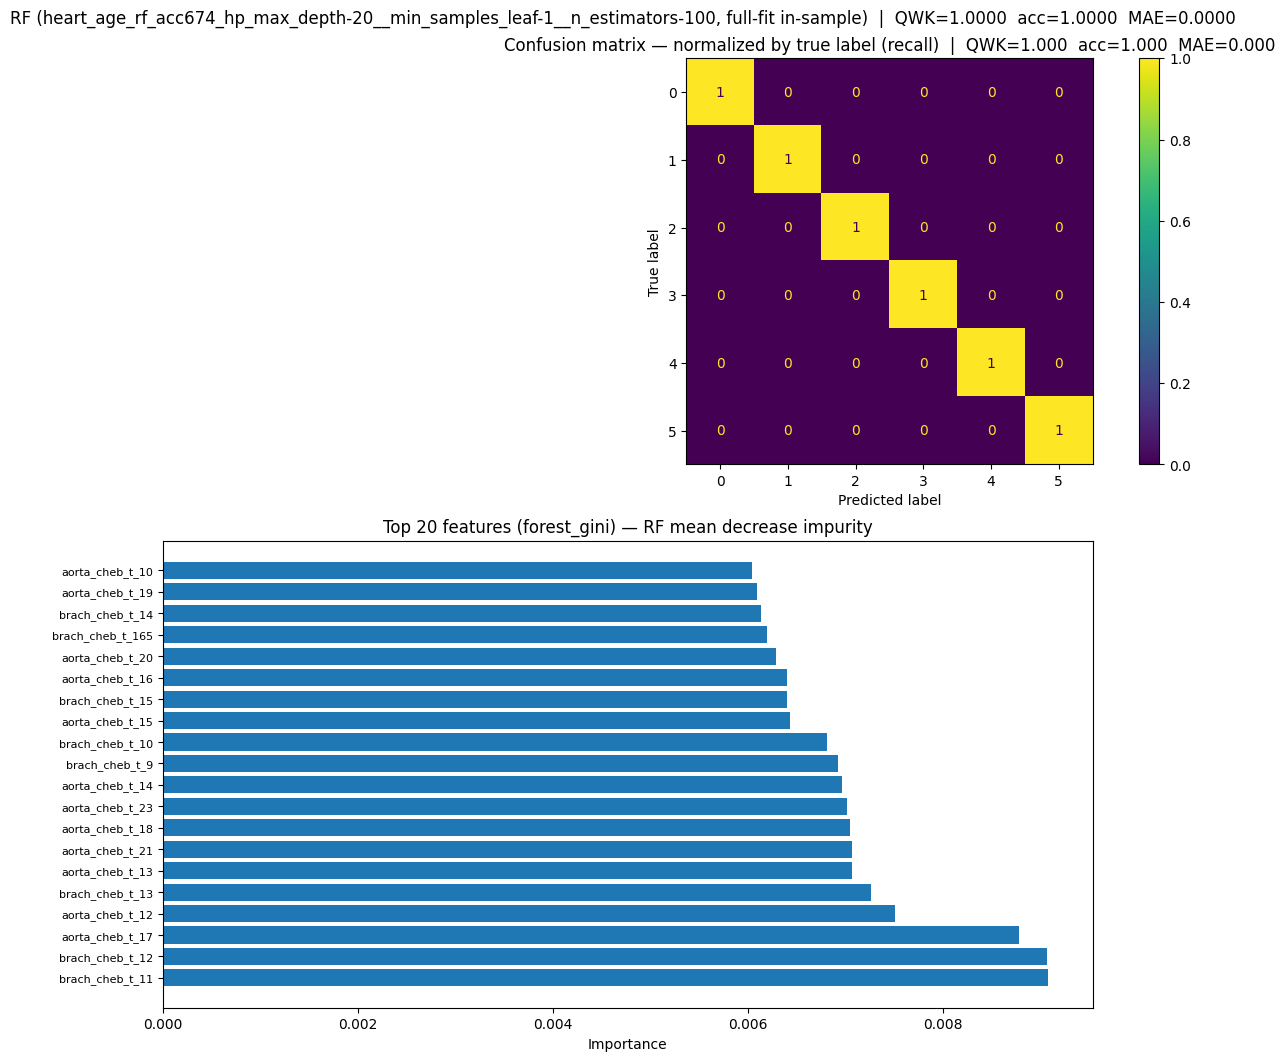

,model,accuracy,mae,f1_macro,qwk,n_eval
0,heart_age_rf_acc674_hp_max_depth-20__min_sampl...,1.0,0.0,1.0,1.0,700


In [11]:
def _resolve_model_paths() -> list[Path]:
    if MODEL_PATHS is not None:
        paths = [Path(p).expanduser().resolve() for p in MODEL_PATHS]
    else:
        paths = [Path(MODEL_PATH).expanduser().resolve()]
    missing = [p for p in paths if not p.is_file()]
    if missing:
        raise FileNotFoundError(
            "Missing saved pipeline(s):\n  " + "\n  ".join(str(p) for p in missing)
        )
    return paths


def _val_subsample_seed() -> int:
    if VAL_SUBSAMPLE_SEED is not None:
        return int(VAL_SUBSAMPLE_SEED)
    if RANDOM_STATE is None:
        raise ValueError("RANDOM_STATE must be set when VAL_SUBSAMPLE_SEED is None.")
    return int(RANDOM_STATE)


def _subsample_validation_indices(n_val: int) -> np.ndarray:
    if n_val <= 0:
        raise ValueError("validation fold is empty")
    if VAL_SUBSAMPLE_N is not None:
        n_take = min(int(VAL_SUBSAMPLE_N), n_val)
    elif VAL_SUBSAMPLE_FRACTION is not None and VAL_SUBSAMPLE_FRACTION < 1.0:
        n_take = max(1, int(round(n_val * float(VAL_SUBSAMPLE_FRACTION))))
    else:
        return np.arange(n_val, dtype=np.int64)
    rng = np.random.RandomState(_val_subsample_seed())
    return np.sort(rng.choice(n_val, size=n_take, replace=False))


def _slice_rows(X, idx: np.ndarray):
    if isinstance(X, pd.DataFrame):
        return X.iloc[idx]
    return np.asarray(X)[idx]


_root = NOTEBOOK_DIR.resolve()
if training_csvs is None:
    train_aorta = _root / "datasets/train/aortaP_train_data.csv"
    train_brach = _root / "datasets/train/brachP_train_data.csv"
else:
    train_aorta, train_brach = Path(training_csvs[0]), Path(training_csvs[1])

if not train_aorta.is_file() or not train_brach.is_file():
    raise FileNotFoundError(
        f"Training CSVs not found ({train_aorta}, {train_brach}). "
        "Set training_csvs or add files under datasets/train/."
    )

if RANDOM_STATE is None:
    raise ValueError("RANDOM_STATE must be an integer (use the same seed as training).")

X_full, y_full = load_train_pair(
    train_aorta,
    train_brach,
    feature_mode=FEATURE_MODE,
    roll_window=ROLL_WINDOW,
    engineered_columns=ENGINEERED_COLUMNS_FOR_MAIN,
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full,
    y_full,
    test_size=VAL_SPLIT,
    random_state=int(RANDOM_STATE),
    stratify=y_full,
)
y_tr = np.asarray(y_tr).ravel()
y_val = np.asarray(y_val).ravel()

val_idx = _subsample_validation_indices(len(y_val))
X_eval = _slice_rows(X_val, val_idx)
y_eval = y_val[val_idx]

print(
    f"Train rows: {len(y_full)}  |  validation fold: {len(y_val)}  |  "
    f"eval subset: {len(y_eval)}  (seed={_val_subsample_seed()})"
)
print(
    f"feature_mode={FEATURE_MODE!r}  roll_window={ROLL_WINDOW}  "
    f"columns={ENGINEERED_COLUMNS_FOR_MAIN!r}"
)

model_paths = _resolve_model_paths()
eval_results: list[dict] = []
holdout_preds: list[tuple[str, np.ndarray]] = []

for model_path in model_paths:
    label = model_path.stem
    pipe_saved = load_fitted_pipeline(model_path)
    print(f"\n--- {label} ({model_path.name}) ---")

    if EVAL_ON_SAVED_FULL_FIT:
        warnings.warn(
            "EVAL_ON_SAVED_FULL_FIT=True: saved pipeline was fit on all training rows in "
            "heart_age_classifier.main(). Validation metrics are in-sample, not holdout.",
            UserWarning,
            stacklevel=2,
        )
        pipe_eval = pipe_saved
    else:
        pipe_eval = clone(pipe_saved)
        pipe_eval.fit(X_tr, y_tr)
        acc_insample = float(accuracy_score(y_eval, pipe_saved.predict(X_eval)))
        acc_holdout = float(accuracy_score(y_eval, pipe_eval.predict(X_eval)))
        print(
            f"  holdout acc (train-fold refit): {acc_holdout:.4f}  |  "
            f"in-sample acc (saved full fit): {acc_insample:.4f}"
        )

    out = evaluate_and_visualize_model(
        pipe_eval,
        X_eval,
        y_eval,
        title_prefix=(
            f"RF ({label}, full-fit in-sample)"
            if EVAL_ON_SAVED_FULL_FIT
            else f"RF ({label}, train-fold refit)"
        ),
        top_n_features=TOP_N_FEATURES,
        random_state=_val_subsample_seed(),
        show=SHOW_FIGURES,
    )
    out["model_path"] = model_path
    out["label"] = label
    eval_results.append(out)
    holdout_preds.append((label, out["y_pred"]))

summary = pd.DataFrame(
    [
        {
            "model": r["label"],
            "accuracy": r["accuracy"],
            "mae": r["mae"],
            "f1_macro": r["f1_macro"],
            "qwk": r["qwk"],
            "n_eval": len(y_eval),
        }
        for r in eval_results
    ]
)
display(summary)

## Side-by-side validation confusion matrices (optional)

Row-normalized matrices on the **same** `y_eval` rows when multiple models are listed in `MODEL_PATHS`.

=== heart_age_rf_acc674_hp_max_depth-20__min_samples_leaf-1__n_estimators-100 — full-fit in-sample on full validation fold n=700; split RANDOM_STATE=13, VAL_SPLIT=0.2 ===
Accuracy: 1.0000  |  MAE: 0.0000  |  QWK: 1.0000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       116
           1      1.000     1.000     1.000       117
           2      1.000     1.000     1.000       119
           3      1.000     1.000     1.000       116
           4      1.000     1.000     1.000       115
           5      1.000     1.000     1.000       117

    accuracy                          1.000       700
   macro avg      1.000     1.000     1.000       700
weighted avg      1.000     1.000     1.000       700



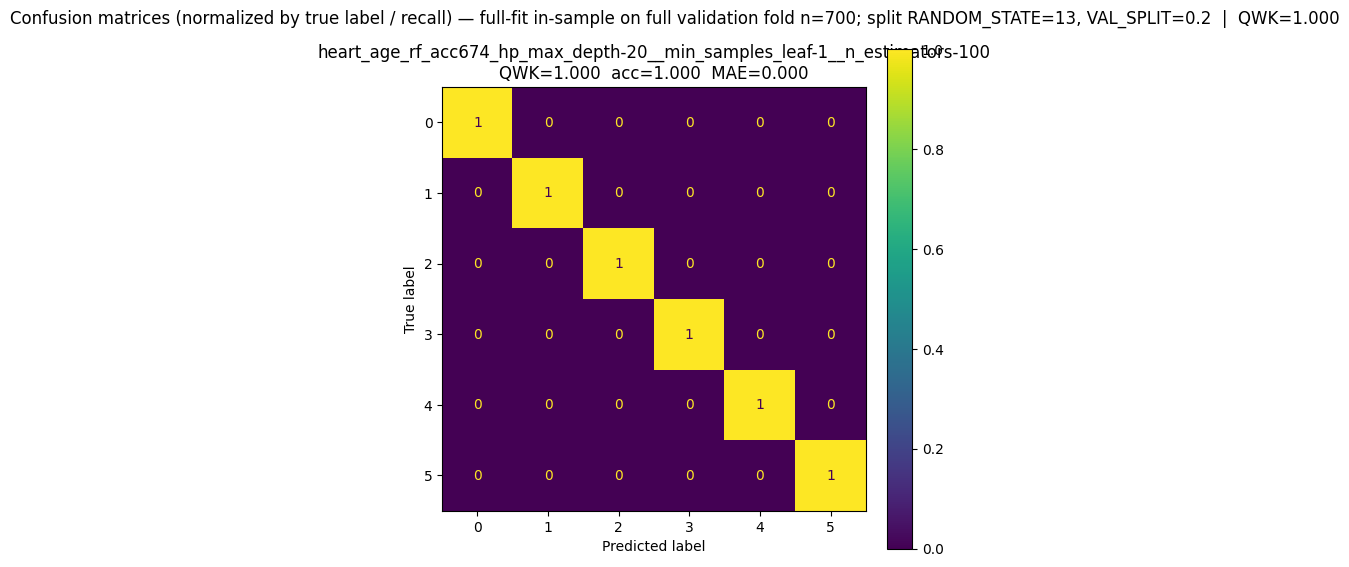

In [12]:
if RUN_SIDE_BY_SIDE_CM and len(holdout_preds) > 0:
    subsample_note = ""
    if len(y_eval) < len(y_val):
        subsample_note = (
            f"random val subset n={len(y_eval)}/{len(y_val)} "
            f"(VAL_SUBSAMPLE_SEED={VAL_SUBSAMPLE_SEED})"
        )
    else:
        subsample_note = f"full validation fold n={len(y_eval)}"

    plot_validation_normalized_confusion_matrices(
        y_eval,
        holdout_preds,
        reference_description=(
            f"{'full-fit in-sample' if EVAL_ON_SAVED_FULL_FIT else 'train-fold refit'} on {subsample_note}; "
            f"split RANDOM_STATE={RANDOM_STATE}, VAL_SPLIT={VAL_SPLIT}"
        ),
        show=SHOW_FIGURES,
    )
else:
    print("Skipping side-by-side CM (RUN_SIDE_BY_SIDE_CM=False or no models evaluated).")